In [1]:
using LinearAlgebra, Printf
DEV = true

function find_local_edkit(start = pwd())
    dir = abspath(start)
    while true
        candidate = joinpath(dir, "src", "EDKit.jl")
        isfile(candidate) && return candidate
        parent = dirname(dir)
        parent == dir && error("Could not locate src/EDKit.jl from $(start)")
        dir = parent
    end
end

if DEV
    include(find_local_edkit())
    using .EDKit
else
    using EDKit
end
using ITensors, ITensorMPS

const HAS_PLOTS = try
    @eval using Plots
    true
catch
    false
end


true

# XXZ operator-growth benchmark with DAOE

This notebook turns the DAOE demo into a small physical benchmark. We evolve a local operator `X_1` in a short open XXZ chain and compare three calculations:

1. exact evolution in the full operator space,
2. unfiltered Pauli-MPS TEBD,
3. TEBD with DAOE filtering after every time step.

For `L = 5`, the full operator space has dimension `4^L = 1024`, so exact comparison is still cheap. The main observables are:

- the overlap with the exact operator,
- the site-resolved operator weight, defined as the total Hilbert-Schmidt weight carried by strings that are non-identity on each site,
- the maximum MPS bond dimension reached during the evolution.


In [2]:
function normalized_overlap(v, w)
    abs(dot(v, w)) / (norm(v) * norm(w))
end

function site_weight_masks(L)
    masks = [falses(4^L) for _ in 1:L]
    for i in 1:4^L
        d = digits(i - 1, base = 4, pad = L)
        for j in 1:L
            masks[j][i] = d[L - j + 1] != 0
        end
    end
    masks
end

function site_weight_profile(v, masks)
    nrm = sum(abs2, v)
    [sum(abs2, v[m]) / nrm for m in masks]
end

bond_dims(psi) = [linkdim(psi, b) for b in 1:length(psi)-1]


bond_dims (generic function with 1 method)

In [3]:
L = 5
Delta = 1.0
dt = 0.05
steps = 20
gamma = 0.4
ps = siteinds("Pauli", L)
B = TensorBasis(L = L, base = 4)
masks = site_weight_masks(L)

h2 = spin((1.0, "xx"), (1.0, "yy"), (Delta, "zz"))
superop = commutation_mat(h2)
K = operator(fill(superop, L - 1), [[i, i + 1] for i in 1:L-1], B)
Uexact = exp(dt * Array(K))
gates = tebd4(fill(superop, L - 1), ps, dt)

D2 = daoe(ps, 2, gamma)
D3 = daoe(ps, 3, gamma)

v_exact = mps2vec(productMPS(ps, ["X", fill("I", L - 1)...]))
psi_raw = vec2mps(v_exact, ps)
psi_d2 = copy(psi_raw)
psi_d3 = copy(psi_raw)


MPS
[1] ((dim=4|id=487|"Pauli,Site,n=1"), (dim=4|id=760|"Link,n=1"))
[2] ((dim=4|id=760|"Link,n=1"), (dim=4|id=185|"Pauli,Site,n=2"), (dim=16|id=852|"Link,n=2"))
[3] ((dim=16|id=852|"Link,n=2"), (dim=4|id=921|"Pauli,Site,n=3"), (dim=16|id=823|"Link,n=3"))
[4] ((dim=16|id=823|"Link,n=3"), (dim=4|id=917|"Pauli,Site,n=4"), (dim=4|id=571|"Link,n=4"))
[5] ((dim=4|id=571|"Link,n=4"), (dim=4|id=709|"Pauli,Site,n=5"))


In [4]:
function run_xxz_benchmark(v_exact, psi_raw, psi_d2, psi_d3, Uexact, gates, D2, D3, masks, dt, steps)
    times = collect(0:dt:steps * dt)
    overlap_raw = zeros(length(times))
    overlap_d2 = zeros(length(times))
    overlap_d3 = zeros(length(times))
    raw_maxbond = zeros(Int, length(times))
    d2_maxbond = zeros(Int, length(times))
    d3_maxbond = zeros(Int, length(times))

    profiles_exact = Matrix{Float64}(undef, length(times), length(masks))
    profiles_d2 = Matrix{Float64}(undef, length(times), length(masks))
    profiles_d3 = Matrix{Float64}(undef, length(times), length(masks))

    for n in eachindex(times)
        v_raw = mps2vec(psi_raw)
        v_d2 = mps2vec(psi_d2)
        v_d3 = mps2vec(psi_d3)

        overlap_raw[n] = normalized_overlap(v_exact, v_raw)
        overlap_d2[n] = normalized_overlap(v_exact, v_d2)
        overlap_d3[n] = normalized_overlap(v_exact, v_d3)
        raw_maxbond[n] = maximum(bond_dims(psi_raw); init = 1)
        d2_maxbond[n] = maximum(bond_dims(psi_d2); init = 1)
        d3_maxbond[n] = maximum(bond_dims(psi_d3); init = 1)

        profiles_exact[n, :] .= site_weight_profile(v_exact, masks)
        profiles_d2[n, :] .= site_weight_profile(v_d2, masks)
        profiles_d3[n, :] .= site_weight_profile(v_d3, masks)

        n == length(times) && break
        v_exact = Uexact * v_exact

        psi_raw = apply(gates, psi_raw)
        normalize!(psi_raw)

        psi_d2 = apply(gates, psi_d2)
        psi_d2 = apply(D2, psi_d2)
        normalize!(psi_d2)

        psi_d3 = apply(gates, psi_d3)
        psi_d3 = apply(D3, psi_d3)
        normalize!(psi_d3)
    end

    (; times, overlap_raw, overlap_d2, overlap_d3, raw_maxbond, d2_maxbond, d3_maxbond, profiles_exact, profiles_d2, profiles_d3)
end

res = run_xxz_benchmark(v_exact, psi_raw, psi_d2, psi_d3, Uexact, gates, D2, D3, masks, dt, steps)
times = res.times
overlap_raw = res.overlap_raw
overlap_d2 = res.overlap_d2
overlap_d3 = res.overlap_d3
raw_maxbond = res.raw_maxbond
d2_maxbond = res.d2_maxbond
d3_maxbond = res.d3_maxbond
profiles_exact = res.profiles_exact
profiles_d2 = res.profiles_d2
profiles_d3 = res.profiles_d3


21×5 Matrix{Float64}:
 1.0       0.0         0.0          0.0          0.0
 1.0       0.001249    1.75483e-7   1.09533e-11  0.0
 0.999994  0.00498469  2.36321e-6   4.57195e-10  2.08801e-33
 0.999969  0.0111741   9.767e-6     3.27963e-9   4.83015e-13
 0.999901  0.0197645   2.53263e-5   1.18581e-8   2.79577e-12
 0.999759  0.030686    5.1343e-5    3.00662e-8   8.88273e-12
 0.999504  0.0438535   8.97e-5      6.18618e-8   2.12317e-11
 0.999089  0.0591689   0.00014225   1.11661e-7   4.29204e-11
 0.998458  0.0765231   0.000211222  1.85259e-7   7.83536e-11
 0.997553  0.0957973   0.000299605  2.91077e-7   1.35051e-10
 0.99631   0.116864    0.000411484  4.41665e-7   2.24718e-10
 0.994657  0.139591    0.00055236   6.55462e-7   3.65232e-10
 0.992525  0.163836    0.000729422  9.5889e-7    5.84861e-10
 0.989839  0.189457    0.000951814  1.3889e-6    9.26902e-10
 0.986523  0.216304    0.00123085   1.99609e-6   1.45645e-9
 0.982502  0.244229    0.00158025   2.84867e-6   2.27012e-9
 0.977703  0.273077 

## Fidelity versus exact evolution

`l = 2` is a strong truncation and quickly suppresses the exact operator growth. `l = 3` keeps much better agreement while still restraining the bond dimension.


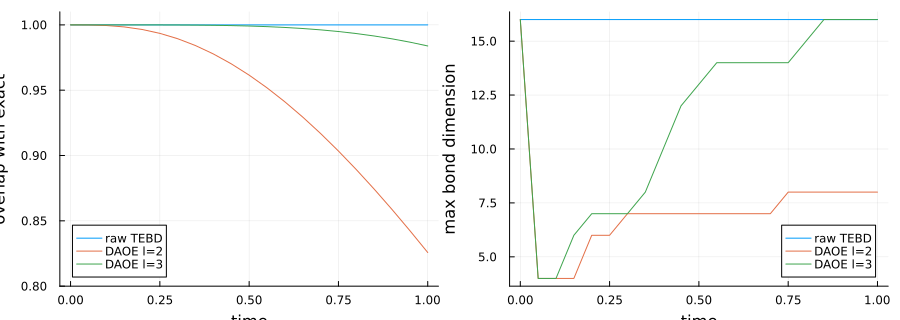

In [5]:
if HAS_PLOTS
    p1 = plot(times, overlap_raw; label = "raw TEBD", xlabel = "time", ylabel = "overlap with exact", ylim = (0.8, 1.01))
    plot!(p1, times, overlap_d2; label = "DAOE l=2")
    plot!(p1, times, overlap_d3; label = "DAOE l=3")
    p2 = plot(times, raw_maxbond; label = "raw TEBD", xlabel = "time", ylabel = "max bond dimension")
    plot!(p2, times, d2_maxbond; label = "DAOE l=2")
    plot!(p2, times, d3_maxbond; label = "DAOE l=3")
    plot(p1, p2; layout = (1, 2), size = (900, 320))
else
    (; times, overlap_raw, overlap_d2, overlap_d3, raw_maxbond, d2_maxbond, d3_maxbond)
end


## Site-resolved operator profile at the final time

This profile is a small-chain analogue of the operator front used in the scrambling literature. On site `j`, it measures the fraction of operator weight carried by strings that are non-identity on that site.


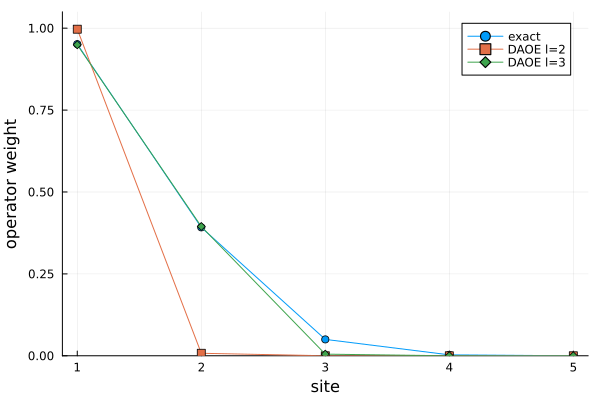

In [6]:
final_profile = (; 
    site = collect(1:L),
    exact = vec(profiles_exact[end, :]),
    daoe_l2 = vec(profiles_d2[end, :]),
    daoe_l3 = vec(profiles_d3[end, :]),
)

if HAS_PLOTS
    plot(final_profile.site, final_profile.exact; label = "exact", marker = :circle, xlabel = "site", ylabel = "operator weight", ylim = (0, 1.05))
    plot!(final_profile.site, final_profile.daoe_l2; label = "DAOE l=2", marker = :square)
    plot!(final_profile.site, final_profile.daoe_l3; label = "DAOE l=3", marker = :diamond)
else
    final_profile
end


For this small XXZ benchmark, `l = 3` is a good compromise: it follows the exact profile closely while still capping the bond growth below the unfiltered trajectory. That is the basic DAOE tradeoff in a genuinely dynamical calculation rather than a string-by-string diagnostic.
